## Rod Cantilever Example

In [255]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [256]:
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

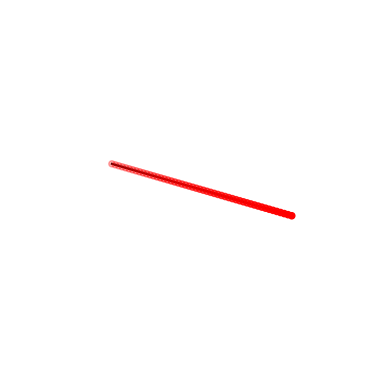

In [ ]:
import numpy as np

import dismech

from dismech.materials import *

b = 0.02
h = 0.001

geom = dismech.GeomParams(rod_r0=0.001,
                          shell_h=0,
                          axs=b*h,
                          ixs1=b*h**3/12,
                          ixs2=h*b**3/12,
                          jxs=b*h**3/6)

material = dismech.Material(density=7800,
                            youngs_rod=200e9,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=True,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()


env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))

env.add_force('pointForces',
              point_force_node_indices=[25, 50,40],
              point_force_vectors=[[0, 5, 0], [0, 0, 10], [0, -10, 0]])


env.set_static()

geo = dismech.Geometry.from_txt(
    '../tests/resources/rod_cantilever/horizontal_rod_n51.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

### Time Stepping

As we are performing a static simulation, we must change gravity for each time step.

In [258]:
fixed_points = np.array([0, 1, 2, 3, 4, 5])

robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)

def update_g(robot: dismech.SoftRobot, t: float):
    """ Update g as a precentage of total time. """
    robot.env.g = robot.env.static_g * t / robot.sim_params.total_time
    return robot

stepper.before_step = update_g

robots, metadata, extra = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

iter: 1, error: 15.000
iter: 2, error: 31141.814
iter: 3, error: 3.466
iter: 4, error: 0.108
current_time:  0.01
iter: 1, error: 0.003
current_time:  0.02
iter: 1, error: 0.000
current_time:  0.03
iter: 1, error: 0.000
current_time:  0.04
iter: 1, error: 0.000
current_time:  0.05
iter: 1, error: 0.000
current_time:  0.060000000000000005
iter: 1, error: 0.000
current_time:  0.07
iter: 1, error: 0.000
current_time:  0.08
iter: 1, error: 0.000
current_time:  0.09
iter: 1, error: 0.000
current_time:  0.09999999999999999
iter: 1, error: 0.000
current_time:  0.10999999999999999
iter: 1, error: 0.000
current_time:  0.11999999999999998
iter: 1, error: 0.000
current_time:  0.12999999999999998
iter: 1, error: 0.000
current_time:  0.13999999999999999
iter: 1, error: 0.000
current_time:  0.15
iter: 1, error: 0.000
current_time:  0.16
iter: 1, error: 0.000
current_time:  0.17
iter: 1, error: 0.000
current_time:  0.18000000000000002
iter: 1, error: 0.000
current_time:  0.19000000000000003
iter: 1, e

In [259]:
t = np.arange(0, robot.sim_params.total_time + robot.sim_params.dt, step=robot.sim_params.dt)
options = dismech.AnimationOptions(y_lim=[-0.005, 0.005],z_lim=[-0.05, 0.05],
                  title='Rod Cantilever (N=51)')

fig = dismech.get_interactive_animation_plotly(robot, t, qs, options)
fig.show()

In [260]:
tip_dofs = dismech.SoftRobot.map_node_to_dof(50)
print("tip xyz:", robots[-1].state.q[tip_dofs])


tip xyz: [ 9.96326748e-02 -2.74629763e-05  7.45312468e-03]


In [261]:
print(f"tip Y: {robots[-1].state.q[tip_dofs[1]]:.6e}")

tip Y: -2.746298e-05
